# Sleep Deprivation Analysis

*By Harald Weedon-Fekjær (hfe@uio.no) using Google Antigravity CLI (Gemini)*

### Research Questions for This Exercise
1. What is the average reaction time of rested subjects on Day 0?
2. On average, by how many milliseconds does reaction time slow down per day of sleep deprivation?
3. Do individuals differ in their baseline rested speed (random intercepts)?
4. Do individuals differ in their vulnerability or rate of slowing over time (random slopes)?


#### Environment Setup & Library Loading
We load `lme4` for linear mixed-effects modeling, `tidyr` for reshaping the wide dataset into long format, and `ggplot2` for exploratory trajectory plots.

In [1]:
library(lme4)
library(tidyr)
library(ggplot2)

# Set clean aesthetic theme for all plots
theme_set(theme_minimal(base_size = 12))

Loading required package: Matrix


Attaching package: 'tidyr'


The following objects are masked from 'package:Matrix':

    expand, pack, unpack




#### Load data
We read `data/sleepstudy_wide.csv` and inspect the data:

In [2]:
# Read wide CSV
sleep_wide <- read.csv("data/sleepstudy_wide.csv")

cat("Dimensions:", dim(sleep_wide), "\n")
head(sleep_wide, 6)


Dimensions: 18 11 


,Subject,day_0,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,308,249.5600,258.7047,250.8006,321.4398,356.8519,414.6901,382.2038,290.1486,430.5853,466.3535
2,309,222.7339,205.2658,202.9778,204.7070,207.7161,215.9618,213.6303,217.7272,224.2957,237.3142
3,310,199.0539,194.3322,234.3200,232.8416,229.3074,220.4579,235.4208,255.7511,261.0125,247.5153
4,330,321.5426,300.4002,283.8565,285.1330,285.7973,297.5855,280.2396,318.2613,305.3495,354.0487
5,331,287.6079,285.0000,301.8206,320.1153,316.2773,293.3187,290.0750,334.8177,293.7469,371.5811
6,332,234.8606,242.8118,272.9613,309.7688,317.4629,309.9976,454.1619,346.8311,330.3003,253.8644


#### Reshape from Wide to Long Format


In [3]:
# Reshape to long format
sleep_long <- pivot_longer(
  sleep_wide,
  cols = starts_with("day_"),
  names_to = "Days",
  names_prefix = "day_",
  values_to = "Reaction"
)

# Format variable types
sleep_long$Days <- as.numeric(sleep_long$Days)
sleep_long$Subject <- factor(sleep_long$Subject)

cat("Long dataset dimensions:", dim(sleep_long), "\n")

head(sleep_long, 12)


Long dataset dimensions: 180 3 


Subject,Days,Reaction
<fct>,<dbl>,<dbl>
308,0,249.5600
308,1,258.7047
308,2,250.8006
308,3,321.4398
308,4,356.8519
308,5,414.6901
308,6,382.2038
308,7,290.1486
308,8,430.5853


<br>
<hr>
<br>

## Exploratory Data Visualization (Plotting First)

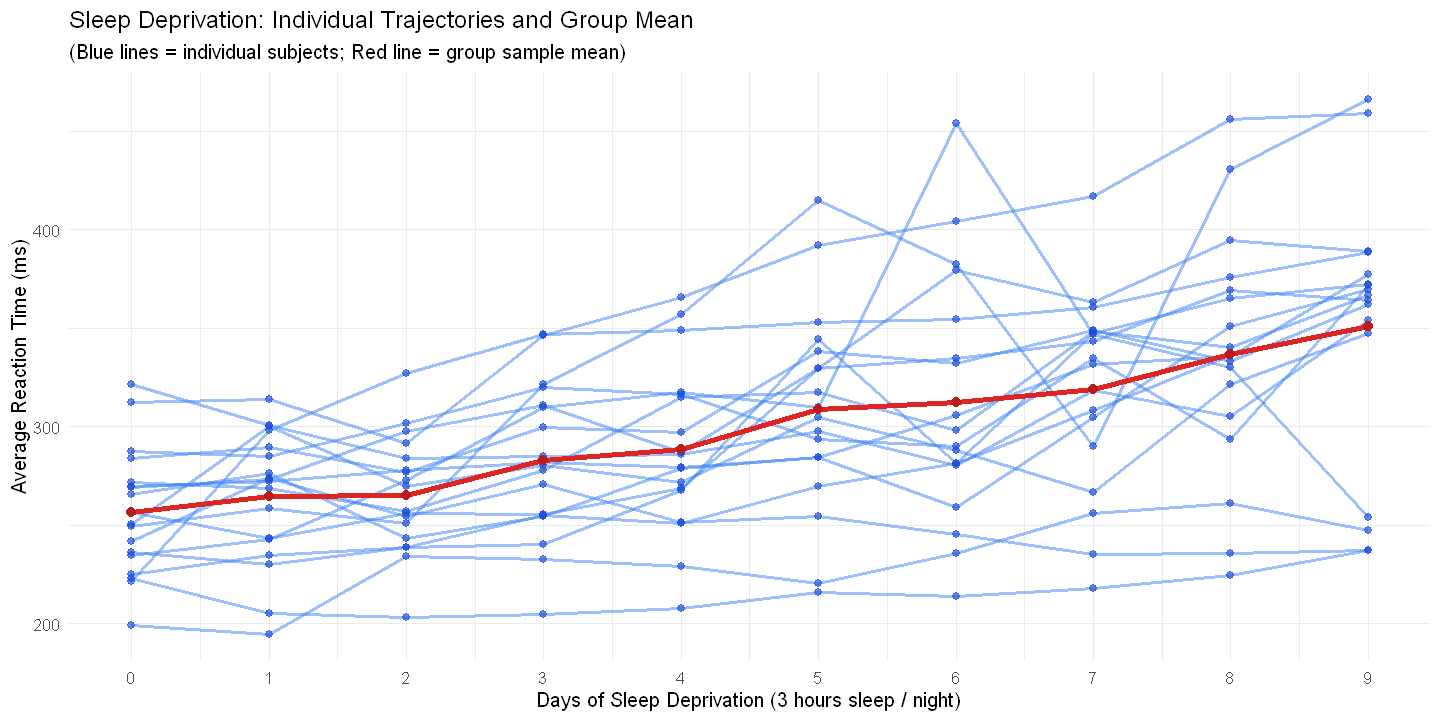

In [4]:
# 1. Spaghetti Plot: All subjects with bold sample average
options(repr.plot.width = 12, repr.plot.height = 6)

p1 <- ggplot(sleep_long, aes(x = Days, y = Reaction, group = Subject)) +
  geom_line(color = "#3b82f6", alpha = 0.5, linewidth = 0.85) +
  geom_point(color = "#1d4ed8", alpha = 0.65, size = 1.8) +
  stat_summary(aes(group = 1), fun = mean, geom = "line", color = "#dc2626", linewidth = 1.5) +
  stat_summary(aes(group = 1), fun = mean, geom = "point", color = "#b91c1c", size = 2.5) +
  scale_x_continuous(breaks = 0:9) +
  labs(
    title = "Sleep Deprivation: Individual Trajectories and Group Mean",
    subtitle = "(Blue lines = individual subjects; Red line = group sample mean)",
    x = "Days of Sleep Deprivation (3 hours sleep / night)",
    y = "Average Reaction Time (ms)"
  )
p1


### Visual Observations:
- **Baseline variability (Intercepts)**: <br> The individual baseline seems to vary a lot.
- **Slowing over time (Slopes)**: <br> Reaction time generally increases with cumulative sleep restriction, but subjects differ markedly in their vulnerability.

<br>
<hr>
<br>

## Mixed models model:

In [5]:
# Model 1: Random Intercept
model_ri <- lmer(Reaction ~ Days + (1 | Subject), data = sleep_long, REML = TRUE)
summary(model_ri)

Linear mixed model fit by REML ['lmerMod']
Formula: Reaction ~ Days + (1 | Subject)
   Data: sleep_long

REML criterion at convergence: 1786.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.2257 -0.5529  0.0109  0.5188  4.2506 

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 1378.2   37.12   
 Residual              960.5   30.99   
Number of obs: 180, groups:  Subject, 18

Fixed effects:
            Estimate Std. Error t value
(Intercept) 251.4051     9.7467   25.79
Days         10.4673     0.8042   13.02

Correlation of Fixed Effects:
     (Intr)
Days -0.371

In [6]:
# Model 2: Random Intercept + Random Slope
model_rs <- lmer(Reaction ~ Days + (Days | Subject), data = sleep_long, REML = TRUE)
summary(model_rs)

Linear mixed model fit by REML ['lmerMod']
Formula: Reaction ~ Days + (Days | Subject)
   Data: sleep_long

REML criterion at convergence: 1743.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.9536 -0.4634  0.0231  0.4634  5.1793 

Random effects:
 Groups   Name        Variance Std.Dev. Corr
 Subject  (Intercept) 612.10   24.741       
          Days         35.07    5.922   0.07
 Residual             654.94   25.592       
Number of obs: 180, groups:  Subject, 18

Fixed effects:
            Estimate Std. Error t value
(Intercept)  251.405      6.825  36.838
Days          10.467      1.546   6.771

Correlation of Fixed Effects:
     (Intr)
Days -0.138

In [7]:
# Confidence intervals for the fixed effects of the random slope model:
confint(model_rs, parm = "(Intercept)")

Computing profile confidence intervals ...



,2.5 %,97.5 %
(Intercept),237.6807,265.1295


In [8]:
# Confidence intervals for the fixed effects trend line of the random slope model:
confint(model_rs, parm = "Days")

Computing profile confidence intervals ...



,2.5 %,97.5 %
Days,7.358653,13.57592


In [9]:
# Confidence intervals for the standard deviations of the random effects:
confint(model_rs, parm = ".sig01")

Computing profile confidence intervals ...



,2.5 %,97.5 %
.sig01,14.38142,37.716


In [10]:
# Confidence interval for the standard derivation of the random trend line (slope) of the random slope model:
confint(model_rs, parm = ".sig03")

Computing profile confidence intervals ...



,2.5 %,97.5 %
.sig03,3.801164,8.753381


#### Model Comparison:

In [11]:
# Likelihood Ratio Test: Random Intercept vs Random Slope
lrt_comp <- anova(model_ri, model_rs)
lrt_comp

refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_ri,4,1802.079,1814.850,-897.0393,1794.079,NA,NA,NA
model_rs,6,1763.939,1783.097,-875.9697,1751.939,42.1393,2,7.072413e-10


**Individual rates of deterioration (slopes) differ significantly across people.**

### Subject-Specific Fitted Trajectories
We extract the fitted values from Model 2 (`model_rs`) to visualize how the mixed model adapts to each individual subject's unique baseline and trajectory.

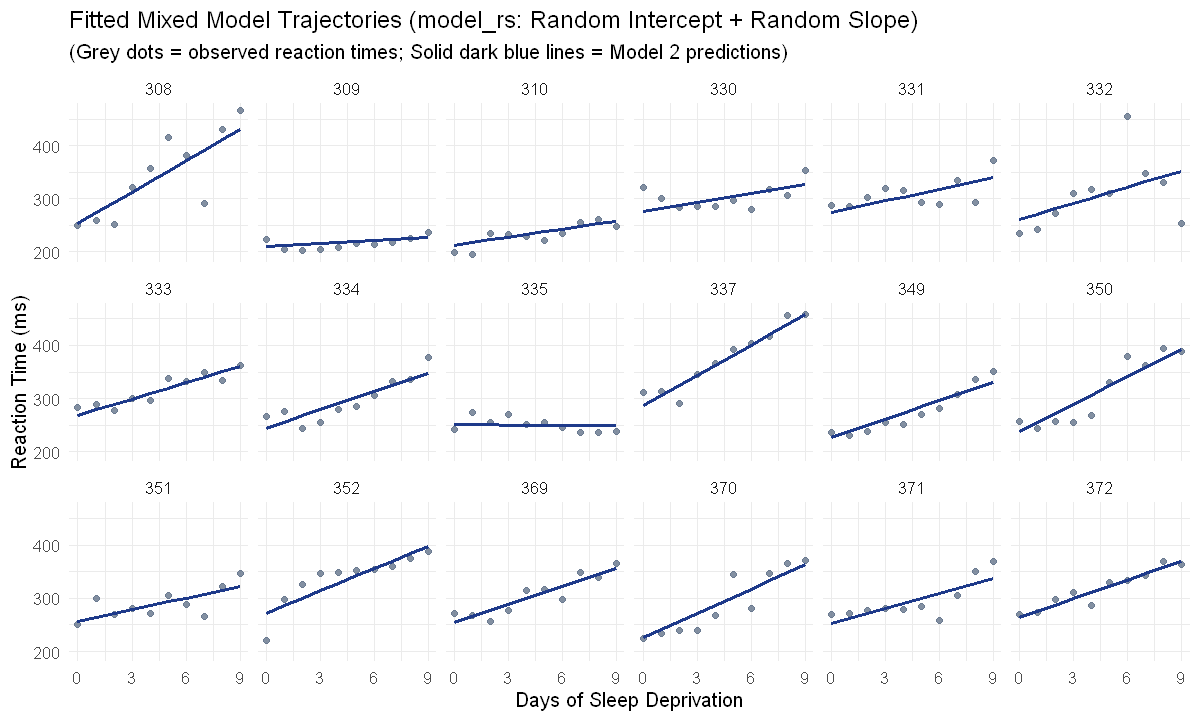

In [12]:
sleep_long$Fitted_RS <- fitted(model_rs)

options(repr.plot.width = 10, repr.plot.height = 6)
p3 <- ggplot(sleep_long, aes(x = Days, y = Reaction)) +
  geom_point(color = "#64748b", alpha = 0.8, size = 1.6) +
  geom_line(aes(y = Fitted_RS), color = "#1e3a8a", linewidth = 1.1) +
  facet_wrap(~ Subject, ncol = 6) +
  scale_x_continuous(breaks = c(0, 3, 6, 9)) +
  labs(
    title = "Fitted Mixed Model Trajectories (model_rs: Random Intercept + Random Slope)",
    subtitle = "(Grey dots = observed reaction times; Solid dark blue lines = Model 2 predictions)",
    x = "Days of Sleep Deprivation",
    y = "Reaction Time (ms)"
  )
p3

<br>
<hr>
<br>

## Model Diagnostics for random slopes model

In [13]:
# Diagnostic Data: Residuals and Fitted Values
diag_data <- data.frame(
  Fitted = fitted(model_rs),
  Residuals = resid(model_rs),
  StdResiduals = resid(model_rs, scaled = TRUE)
)

# Specify size of plots:
options(repr.plot.width = 8, repr.plot.height = 4)

**Residuals vs. Fitted values**: check for linearity and homoscedasticity (equal variance).

`geom_smooth()` using formula = 'y ~ x'


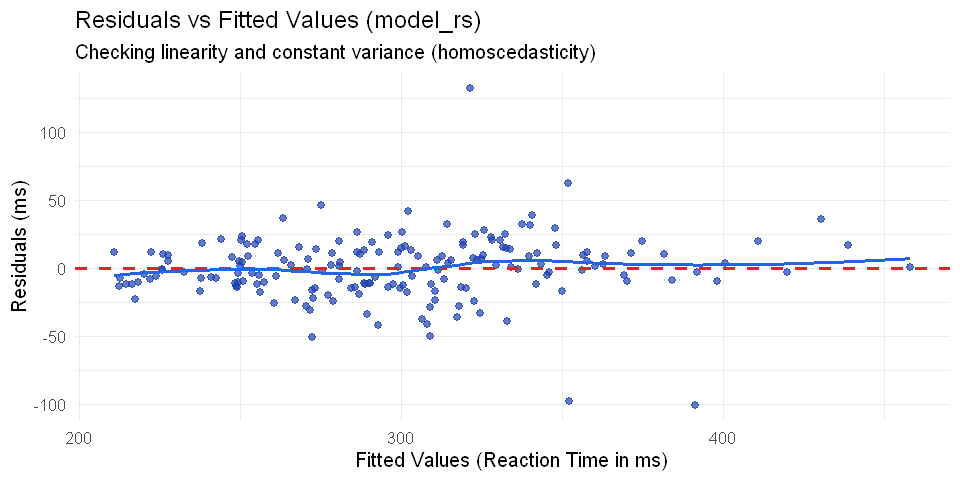

In [14]:
p_diag1 <- ggplot(diag_data, aes(x = Fitted, y = Residuals)) +
  geom_point(color = "#1e40af", alpha = 0.7, size = 2) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "#dc2626", linewidth = 0.9) +
  geom_smooth(method = "loess", se = FALSE, color = "#2563eb", linewidth = 0.9) +
  labs(
    title = "Residuals vs Fitted Values (model_rs)",
    subtitle = "Checking linearity and constant variance (homoscedasticity)",
    x = "Fitted Values (Reaction Time in ms)",
    y = "Residuals (ms)"
  )
p_diag1

**Normal Q-Q plot of residuals**: check normality of within-subject residual errors $\epsilon_{ij}$.

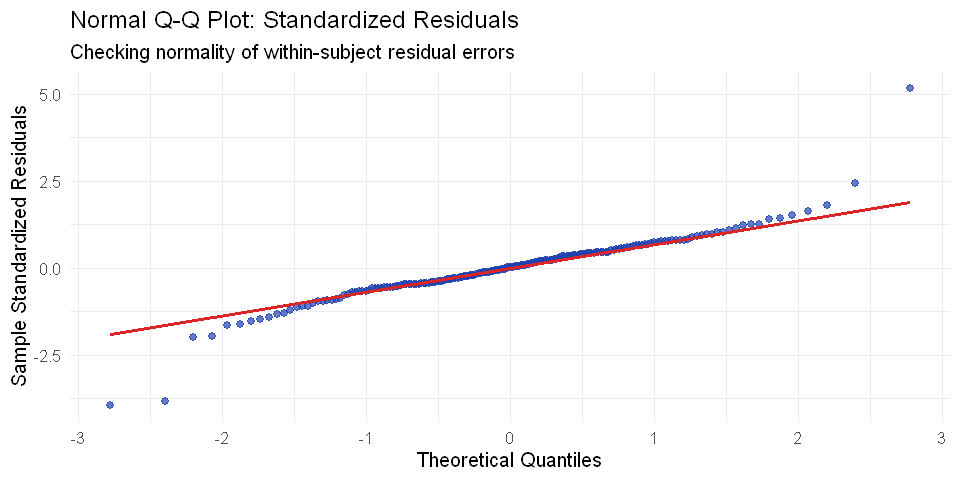

In [15]:
p_diag2 <- ggplot(diag_data, aes(sample = StdResiduals)) +
  stat_qq(color = "#1e40af", alpha = 0.7, size = 2) +
  stat_qq_line(color = "#dc2626", linewidth = 0.9) +
  labs(
    title = "Normal Q-Q Plot: Standardized Residuals",
    subtitle = "Checking normality of within-subject residual errors",
    x = "Theoretical Quantiles",
    y = "Sample Standardized Residuals"
  )
p_diag2

**Normal Q-Q plots of random effects**: check normality of subject random intercepts $u_{0j}$ and slopes $u_{1j}$.

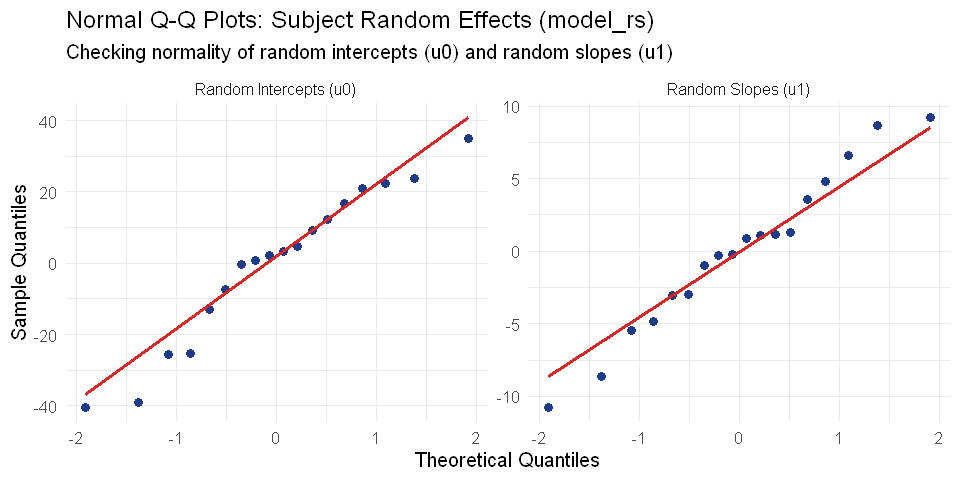

In [16]:
re_df <- as.data.frame(ranef(model_rs)$Subject)
names(re_df) <- c("Random_Intercept", "Random_Slope")
re_long <- pivot_longer(re_df, cols = c("Random_Intercept", "Random_Slope"),
                        names_to = "Effect", values_to = "Estimate")
re_long$Effect <- factor(re_long$Effect, levels = c("Random_Intercept", "Random_Slope"),
                         labels = c("Random Intercepts (u0)", "Random Slopes (u1)"))
p_diag3 <- ggplot(re_long, aes(sample = Estimate)) +
  stat_qq(color = "#1e3a8a", size = 2.2) +
  stat_qq_line(color = "#dc2626", linewidth = 0.9) +
  facet_wrap(~ Effect, scales = "free") +
  labs(
    title = "Normal Q-Q Plots: Subject Random Effects (model_rs)",
    subtitle = "Checking normality of random intercepts (u0) and random slopes (u1)",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  )
p_diag3

### Diagnostic Observations:
- **Linearity & Homoscedasticity**: Residuals are evenly distributed around zero without any severe curve or fanning pattern across fitted values.
- **Normality**: Both within-subject errors and random effects track the theoretical normal line closely, confirming the model assumptions are reasonably satisfied.

## Answers to the Research Questions

<pre>
========================================================================================
                           EXERCISE ANSWERS & RESULTS SUMMARY                           
========================================================================================

QUESTION 1: What is the average reaction time of rested subjects on Day 0?
  -> Fixed Intercept: 251.4 ms with confidence intervall [237.7, 265.1] ms
  -> Interpretation: Rested subjects on Day 0 have an estimated population mean
     reaction time of ~251.4 ms.

QUESTION 2: On average, by how many ms does reaction time slow down per day of sleep deprivation?
  -> Fixed Slope: +10.5 ms/day with confidence intervall [7.4, 13.6] ms/day,
  -> Interpretation: For each additional day of sleep restriction, reaction time slows down
     by an average of approximately 10.5 ms per day.

QUESTION 3: Do individuals differ in their baseline rested speed (random intercepts)?
  -> Subject Intercept standard derivation: 24.7 ms with confidence intervall [14.4, 37.7]
  -> Interpretation: Baseline rested reaction times vary substantially
     across individuals.

QUESTION 4: Do individuals differ in their vulnerability or rate of slowing over time (random slopes)?
  -> Subject Slope standard derivation: 5.9 ms/day with confidence intervall [3.8, 8.8] ms/day
  -> Random effect correlation between baseline & slope: r = 0.1
  -> Likelihood Ratio Test: p = 7.1e-10 (AIC: 1802.1 vs 1763.9)
  -> Interpretation: Individuals differ significantly in their rate of slowing over
     time. Adding random slopes yields a highly significant improvement in model fit.
========================================================================================</pre>